In [23]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

In [4]:
# ============================================================
# PFT IDs
# ============================================================

pfts = np.array([1, 2, 3, 4, 5, 6, 7, 8])

# ============================================================
# BASELINE MODEL
# ============================================================

baseline_slopes = np.array([
    -0.0836,
    -0.0286,
    -0.1734,
    -0.1078,
    -0.0176,
    -0.2094,
    -0.1121,
    -0.1122
])

baseline_intercepts = np.array([
    -2.0966,
    -1.9611,
    -2.0644,
    -1.9806,
    -1.8745,
    -2.0316,
    -1.8655,
    -2.0662
])

# ============================================================
# MONTHLY MORTALITY MODEL
# ============================================================

mm_slopes = np.array([
    -0.1074,
    -0.0514,
    -0.1011,
    -0.0896,
    -0.0254,
    -0.1848,
    -0.1159,
    -0.0897
])

mm_intercepts = np.array([
    -2.0820,
    -1.9383,
    -1.9519,
    -1.9302,
    -1.8644,
    -2.0132,
    -1.8703,
    -2.0200
])

# ============================================================
# DROUGHT MORTALITY MODEL
# ============================================================

dm_slopes = np.array([
    -0.2857,
    -0.3388,
    -0.2896,
    -0.3094,
    -0.4320,
    -0.1957,
    -0.1954,
    -0.0971
])

dm_intercepts = np.array([
    -1.6046,
    -1.3773,
    -1.5704,
    -1.1174,
    -1.2862,
    -1.9279,
    -1.8266,
    -2.0001
])

# ============================================================
# OBSERVED RELATIONSHIP
# ============================================================

S_obs_mort = -0.46
intercept_mort = -1.96


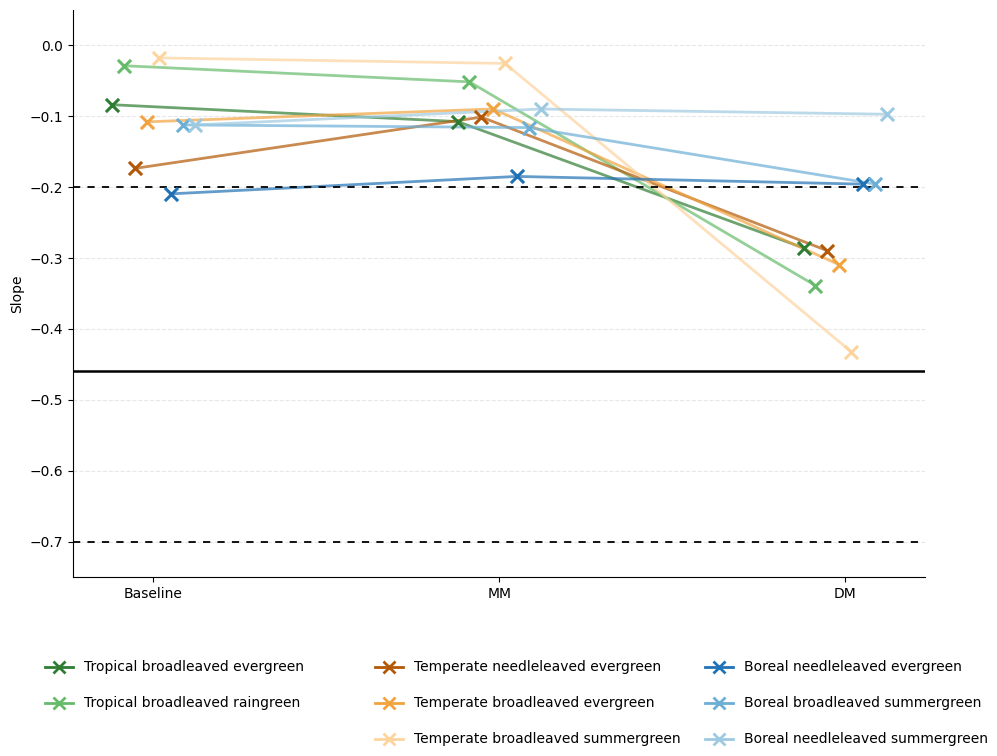

Saved: /home/druijsch/scripts/2026_05_18_scatter_per_PFT_type/styled_slope_transition_plot_ecological_colors.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PFT NAMES + COLORS
# ============================================================

pfts = {
    "Tropical broadleaved evergreen": "#2e7d32",
    "Tropical broadleaved raingreen": "#66bb6a",

    "Temperate needleleaved evergreen": "#b35806",
    "Temperate broadleaved evergreen": "#f1a340",
    "Temperate broadleaved summergreen": "#fdd49e",

    "Boreal needleleaved evergreen": "#2171b5",
    "Boreal broadleaved summergreen": "#6baed6",
    "Boreal needleleaved summergreen": "#9ecae1",
}

pft_names = list(pfts.keys())
colors = list(pfts.values())

# ============================================================
# OBSERVED REFERENCE
# ============================================================

obs_mean = -0.46
obs_ci_low = -0.70
obs_ci_high = -0.20

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(11, 9))

# ============================================================
# X POSITIONS
# ============================================================

x_positions = {
    "Baseline": 0,
    "MM": 1,
    "DM": 2
}

# small offsets so points do not overlap
offsets = np.linspace(-0.12, 0.12, len(pft_names))

# ============================================================
# PLOT PFTS
# ============================================================

for i, pft in enumerate(pft_names):

    x_vals = np.array([
        x_positions["Baseline"],
        x_positions["MM"],
        x_positions["DM"]
    ]) + offsets[i]

    y_vals = np.array([
        baseline_slopes[i],
        mm_slopes[i],
        dm_slopes[i]
    ])

    # connecting line
    ax.plot(
        x_vals,
        y_vals,
        color=colors[i],
        alpha=0.7,
        linewidth=2,
        zorder=2
    )

    # points
    ax.scatter(
        x_vals,
        y_vals,
        color=colors[i],
        s=90,
        marker="x",
        linewidth=2.2,
        zorder=3
    )

# ============================================================
# OBSERVED REFERENCE
# ============================================================

# mean
ax.axhline(
    obs_mean,
    color="black",
    linewidth=1.8
)

# confidence interval
ax.axhline(
    obs_ci_low,
    color="black",
    linestyle=(0, (4, 4)),
    linewidth=1.3
)

ax.axhline(
    obs_ci_high,
    color="black",
    linestyle=(0, (4, 4)),
    linewidth=1.3
)

# ============================================================
# AXES
# ============================================================

ax.set_xticks([0, 1, 2])

ax.set_xticklabels([
    "Baseline",
    "MM",
    "DM"
])

ax.set_ylabel("Slope")

ax.set_ylim([-0.75, 0.05])

# ============================================================
# OPTIONAL STYLING
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

import matplotlib.lines as mlines

# ============================================================
# CUSTOM LEGEND LAYOUT
# ============================================================

handles = []
labels = []

for i, pft in enumerate(pft_names):

    handles.append(
        mlines.Line2D(
            [], [],
            color=colors[i],
            marker='x',
            linestyle='-',
            linewidth=2,
            markersize=8,
            markeredgewidth=2
        )
    )

    labels.append(pft)

# desired legend arrangement
layout = [
    [0, 2, 5],
    [1, 3, 6],
    [None, 4, 7]
]

fig = plt.gcf()

# figure coordinates
x0, y0 = 0.10, 0.15
dx, dy = 0.30, 0.04

for r, row in enumerate(layout):

    for c, idx in enumerate(row):

        if idx is None:
            continue

        line = handles[idx]
        label = labels[idx]

        # line sample
        fig.add_artist(
            mlines.Line2D(
                [x0 + c*dx, x0 + c*dx + 0.025],
                [y0 - r*dy, y0 - r*dy],
                transform=fig.transFigure,
                color=line.get_color(),
                linewidth=2
            )
        )

        # marker sample
        fig.add_artist(
            mlines.Line2D(
                [x0 + c*dx + 0.0125],
                [y0 - r*dy],
                transform=fig.transFigure,
                color=line.get_color(),
                marker='x',
                linestyle='',
                markersize=8,
                markeredgewidth=2
            )
        )

        # text
        fig.text(
            x0 + c*dx + 0.035,
            y0 - r*dy,
            label,
            fontsize=10,
            va="center"
        )

# # ============================================================
# # LAYOUT
# # ============================================================

plt.subplots_adjust(bottom=0.25)

# # ============================================================
# # LAYOUT
# # ============================================================

# plt.tight_layout()

# # ============================================================
# # SAVE
# # ============================================================

outfile = (
    "/home/druijsch/scripts/"
    "2026_05_18_scatter_per_PFT_type/"
    "styled_slope_transition_plot_ecological_colors.png"
)

# plt.savefig(
#     outfile,
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

print(f"Saved: {outfile}")

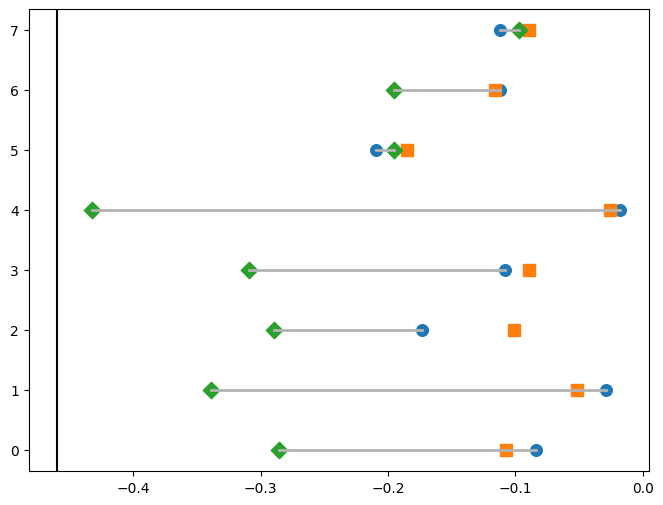

In [6]:
fig, ax = plt.subplots(figsize=(8,6))

y = np.arange(len(pft_names))

for i in range(len(pft_names)):
    ax.plot(
        [baseline_slopes[i], dm_slopes[i]],
        [y[i], y[i]],
        color="0.7",
        lw=2
    )

ax.scatter(baseline_slopes, y, marker="o", s=70, label="Baseline")
ax.scatter(mm_slopes, y, marker="s", s=70, label="MM")
ax.scatter(dm_slopes, y, marker="D", s=70, label="DM")

ax.axvline(obs_mean,color="k")

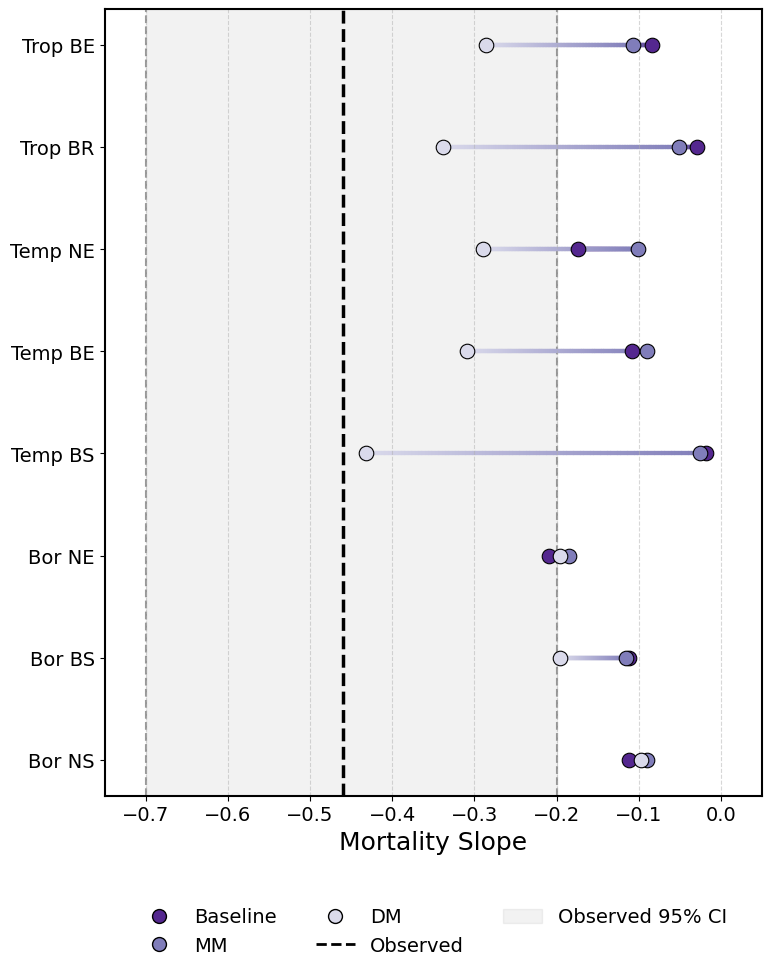

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# ============================================================
# DATA
# ============================================================

baseline_slopes = np.array([
    -0.0836,
    -0.0286,
    -0.1734,
    -0.1078,
    -0.0176,
    -0.2094,
    -0.1121,
    -0.1122
])

mm_slopes = np.array([
    -0.1074,
    -0.0514,
    -0.1011,
    -0.0896,
    -0.0254,
    -0.1848,
    -0.1159,
    -0.0897
])

dm_slopes = np.array([
    -0.2857,
    -0.3388,
    -0.2896,
    -0.3094,
    -0.4320,
    -0.1957,
    -0.1954,
    -0.0971
])

# ============================================================
# PFT NAMES (YOUR ORDER)
# ============================================================

pft_names = [
    "Trop BE",
    "Trop BR",
    "Temp NE",
    "Temp BE",
    "Temp BS",
    "Bor NE",
    "Bor BS",
    "Bor NS",
]

# ============================================================
# OBSERVED RELATIONSHIP
# ============================================================

obs_mean = -0.46
obs_ci_low = -0.70
obs_ci_high = -0.20

# ============================================================
# STYLING
# ============================================================

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15
})

# Purple palette (similar feel to your loss figure)
baseline_color = "#54278f"
mm_color = "#807dba"
dm_color = "#dadaeb"

# ============================================================
# GRADIENT LINE FUNCTION
# ============================================================

def draw_gradient_line(x0, x1, y, color_start, color_end, n=100):

    xs = np.linspace(x0, x1, n)

    c0 = np.array(mcolors.to_rgb(color_start))
    c1 = np.array(mcolors.to_rgb(color_end))

    for i in range(n - 1):

        t = i / (n - 1)

        color = c0 * (1 - t) + c1 * t

        plt.plot(
            xs[i:i+2],
            [y, y],
            color=color,
            linewidth=3,
            alpha=0.9,
            zorder=1
        )

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 10))

# y positions
y = np.arange(len(pft_names))

# ============================================================
# OBSERVED REFERENCE
# ============================================================

# confidence interval
ax.axvspan(
    obs_ci_low,
    obs_ci_high,
    color="grey",
    alpha=0.1,
    zorder=0
)

# CI boundaries
ax.axvline(
    obs_ci_low,
    color="grey",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    zorder=0
)

ax.axvline(
    obs_ci_high,
    color="grey",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    zorder=0
)

# observed mean
ax.axvline(
    obs_mean,
    color="black",
    linestyle="--",
    linewidth=2.5,
    zorder=0
)

# ============================================================
# DUMBBELLS
# ============================================================

for i in range(len(pft_names)):

    # Baseline → MM
    draw_gradient_line(
        baseline_slopes[i],
        mm_slopes[i],
        y[i],
        baseline_color,
        mm_color
    )

    # MM → DM
    draw_gradient_line(
        mm_slopes[i],
        dm_slopes[i],
        y[i],
        mm_color,
        dm_color
    )

# ============================================================
# POINTS
# ============================================================

ax.scatter(
    baseline_slopes,
    y,
    s=110,
    color=baseline_color,
    edgecolor="k",
    linewidth=0.8,
    zorder=3,
    label="Baseline"
)

ax.scatter(
    mm_slopes,
    y,
    s=110,
    color=mm_color,
    edgecolor="k",
    linewidth=0.8,
    zorder=3,
    label="MM"
)

ax.scatter(
    dm_slopes,
    y,
    s=110,
    color=dm_color,
    edgecolor="k",
    linewidth=0.8,
    zorder=3,
    label="DM"
)

# ============================================================
# AXES
# ============================================================

ax.set_yticks(y)
ax.set_yticklabels(pft_names)

# tropical at top, boreal at bottom
ax.invert_yaxis()

ax.set_xlabel("Mortality Slope")

ax.set_xlim(-0.75, 0.05)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

# ============================================================
# SPINES
# ============================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0], [0],
        linestyle='',
        marker='o',
        markerfacecolor=baseline_color,
        markeredgecolor='k',
        markersize=10,
        label='Baseline'
    ),

    Line2D(
        [0], [0],
        linestyle='',
        marker='o',
        markerfacecolor=mm_color,
        markeredgecolor='k',
        markersize=10,
        label='MM'
    ),

    Line2D(
        [0], [0],
        linestyle='',
        marker='o',
        markerfacecolor=dm_color,
        markeredgecolor='k',
        markersize=10,
        label='DM'
    ),

    Line2D(
        [0], [0],
        color='black',
        linewidth=2,
        linestyle="--",
        label='Observed'
    ),
    
    Patch(
        facecolor="grey",
        alpha=0.1,
        edgecolor="grey",
        label="Observed 95% CI"
    )
]


ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "/home/druijsch/scripts/2026_06_01_mortality_slopes_plot/slope_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()